<a href="https://colab.research.google.com/github/divyasri232007-collab/QR-Attendance-System/blob/main/pneumonia%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile

zip_ref = zipfile.ZipFile('/content/pneumonia (2).zip', 'r')  # change name if needed
zip_ref.extractall('/content')
zip_ref.close()

In [3]:
import os
print(os.listdir("/content"))

['.config', 'pneumonia (2).zip', 'pneumonia', 'sample_data']


In [4]:
base_dir = "/content/pneumonia"

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [7]:
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 6800 images belonging to 2 classes.
Found 1700 images belonging to 2 classes.
Found 30 images belonging to 2 classes.


In [8]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Custom layers
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
213/213 ━━━━━━━━━━━━━━━━━━━━ 1607s 7s/step - accuracy: 0.6047 - loss: 0.6621 - val_accuracy: 0.7112 - val_loss: 0.6036
Epoch 2/3
213/213 ━━━━━━━━━━━━━━━━━━━━ 1592s 7s/step - accuracy: 0.7118 - loss: 0.5813 - val_accuracy: 0.7941 - val_loss: 0.5201
Epoch 3/3
213/213 ━━━━━━━━━━━━━━━━━━━━ 1523s 7s/step - accuracy: 0.7579 - loss: 0.5266 - val_accuracy: 0.7853 - val_loss: 0.5050


In [11]:
model.save("pneumonia_model.h5")

In [12]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.8667 - loss: 0.4524
Test Accuracy: 0.8666666746139526


In [13]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/pneumonia/test/PNEUMONIA/person52_virus_106.jpeg"  # change if needed

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: PNEUMONIA")
else:
    print("Prediction: NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction: PNEUMONIA


In [14]:
import tensorflow as tf

for layer in base_model.layers[-10:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(train_data, validation_data=val_data, epochs=2)

Epoch 1/2
213/213 ━━━━━━━━━━━━━━━━━━━━ 1798s 8s/step - accuracy: 0.8603 - loss: 0.3531 - val_accuracy: 0.5547 - val_loss: 0.6364
Epoch 2/2
213/213 ━━━━━━━━━━━━━━━━━━━━ 1808s 8s/step - accuracy: 0.9044 - loss: 0.2460 - val_accuracy: 0.8247 - val_loss: 0.3607


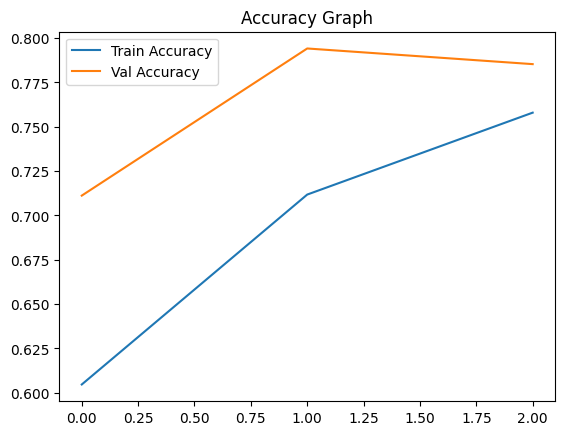

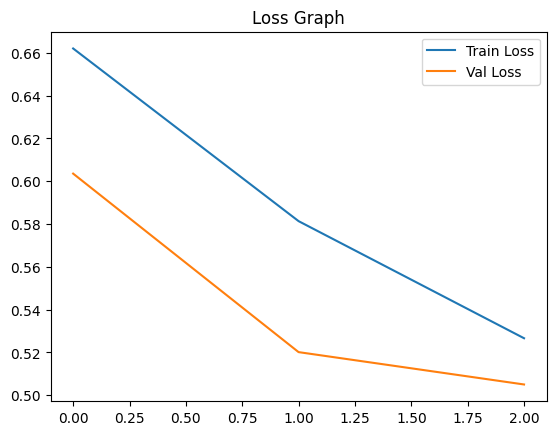

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

preds = model.predict(test_data)
pred_classes = (preds > 0.5).astype(int)

true_classes = test_data.classes

print(confusion_matrix(true_classes, pred_classes))
print(classification_report(true_classes, pred_classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
[[ 3 12]
 [ 6  9]]
              precision    recall  f1-score   support

           0       0.33      0.20      0.25        15
           1       0.43      0.60      0.50        15

    accuracy                           0.40        30
   macro avg       0.38      0.40      0.38        30
weighted avg       0.38      0.40      0.38        30

